In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

print("Path to dataset files:", path)



Path to dataset files: /kaggle/input/neu-surface-defect-database


In [ ]:
# Paths & hyperparams
DATASET_PATH = "/kaggle/input/neu-surface-defect-database/NEU-DET/train/images"
IMG_SIZE     = 200
BATCH_SIZE   = 32
SEED         = 42
NUM_CLASSES  = 6
EPOCHS_FE    = 5
EPOCHS_FT    = 3


In [ ]:
# Quick sanity check: should list six folders
print("Classes found:", os.listdir(DATASET_PATH))

Classes found: ['inclusion', 'scratches', 'pitted_surface', 'patches', 'crazing', 'rolled-in_scale']


In [ ]:
#Load & Split the Dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)


# Prefetch for performance
AUTOTUNE  = tf.data.AUTOTUNE
train_ds  = train_ds.prefetch(AUTOTUNE)
val_ds    = val_ds.prefetch(AUTOTUNE)



Found 1440 files belonging to 6 classes.
Using 1152 files for training.
Found 1440 files belonging to 6 classes.
Using 288 files for validation.


In [ ]:
#Data Augmentation Pipeline


data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])




In [ ]:
#Build the Model

# 4.1 Base ResNet50 feature extractor (frozen)
base_model = ResNet50(
    weights="imagenet",
    include_top=False,    #
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

# 4.2 Custom classification head
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)


x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)



model.compile(
    optimizer=optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 200, 200,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 200, 200)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 200, 200)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 200, 200)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 200, 200,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 200, 200,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │      1,542 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#Train: Feature-Extraction Phase


es = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_fe = model.fit(
#This is the training loop for the feature extraction phase.
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FE,
    callbacks=[es]
)


Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 283s 8s/step - accuracy: 0.7264 - loss: 0.8391 - val_accuracy: 0.9861 - val_loss: 0.0309
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 268s 8s/step - accuracy: 0.9867 - loss: 0.0457 - val_accuracy: 0.9861 - val_loss: 0.0238
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 321s 7s/step - accuracy: 0.9933 - loss: 0.0233 - val_accuracy: 0.9931 - val_loss: 0.0387
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 322s 7s/step - accuracy: 0.9866 - loss: 0.0393 - val_accuracy: 0.9965 - val_loss: 0.0141
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 322s 7s/step - accuracy: 0.9939 - loss: 0.0245 - val_accuracy: 0.9931 - val_loss: 0.0171


In [ ]:
#Optional: Fine-Tune Top Layers

# Unfreeze last conv-block of ResNet50
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False




model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


#Train the model for the fine-tuning phase:
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=[es]
)


Epoch 1/3
36/36 ━━━━━━━━━━━━━━━━━━━━ 381s 10s/step - accuracy: 0.7300 - loss: 1.0752 - val_accuracy: 0.9931 - val_loss: 0.0103
Epoch 2/3
36/36 ━━━━━━━━━━━━━━━━━━━━ 377s 10s/step - accuracy: 0.9475 - loss: 0.1407 - val_accuracy: 0.9931 - val_loss: 0.0173
Epoch 3/3
36/36 ━━━━━━━━━━━━━━━━━━━━ 382s 10s/step - accuracy: 0.9788 - loss: 0.0752 - val_accuracy: 0.9931 - val_loss: 0.0186


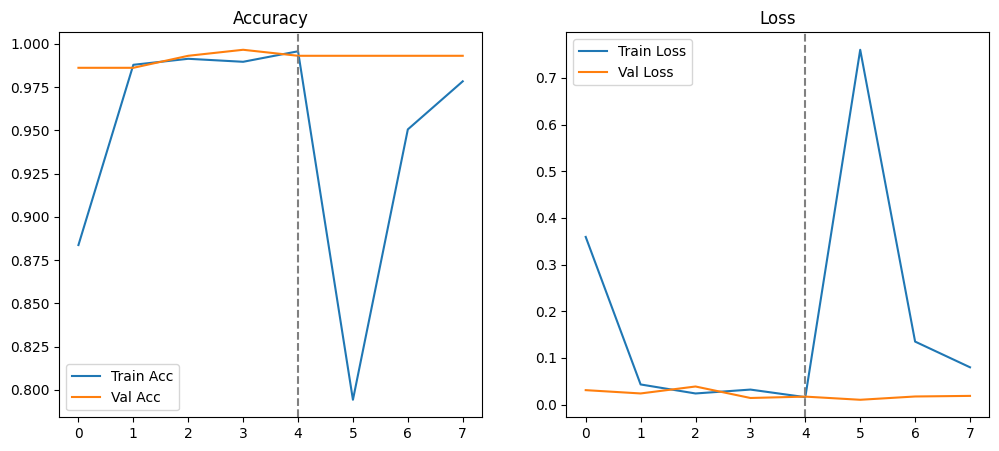

In [ ]:
#Evaluate & Plot Learning Curves

# Combine histories
acc      = history_fe.history["accuracy"] + history_ft.history["accuracy"]
val_acc  = history_fe.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss     = history_fe.history["loss"] + history_ft.history["loss"]
val_loss = history_fe.history["val_loss"] + history_ft.history["val_loss"]
total_epochs = len(acc)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(total_epochs), acc, label="Train Acc")
plt.plot(range(total_epochs), val_acc, label="Val Acc")
plt.axvline(EPOCHS_FE-1, linestyle="--", color="gray")
plt.title("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(range(total_epochs), loss, label="Train Loss")
plt.plot(range(total_epochs), val_loss, label="Val Loss")
plt.axvline(EPOCHS_FE-1, linestyle="--", color="gray")
plt.title("Loss"); plt.legend()

plt.show()

